In [1]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])
print(arr.mean())      # 3.0 (평균)
print(arr.sum())       # 15  (합계)
print(arr * 2)         # [ 2  4  6  8 10]  (벡터 연산)
print(arr[arr > 3])    # [4 5] (조건 필터링)

# 2차원 배열 + 슬라이싱
m = np.array([[1, 2, 3], 
              [4, 5, 6]])
print(m.shape)         # (2, 3) 행·열 크기
print(m[:, 1])         # [2 5] (모든 행, 1번 열)
print(np.unique([1,1,2,3,3]))  # [1 2 3] 고유값

3.0
15
[ 2  4  6  8 10]
[4 5]
(2, 3)
[2 5]
[1 2 3]


In [2]:
import pandas as pd

# 1) Series (1차원)
s = pd.Series([100, 200, 300], index=['A', 'B', 'C'])
print(s['B'])   # 200

# 2) DataFrame (2차원) — 딕셔너리로 생성
data = {'이름': ['철수', '영희', '민수'],
        '나이': [24, 25, 23],
        '점수': [90, 85, 95]}
df = pd.DataFrame(data)
print(df)
print(df.describe())   # 평균·표준편차·최대/최소 자동 요약

200
   이름  나이  점수
0  철수  24  90
1  영희  25  85
2  민수  23  95
         나이    점수
count   3.0   3.0
mean   24.0  90.0
std     1.0   5.0
min    23.0  85.0
25%    23.5  87.5
50%    24.0  90.0
75%    24.5  92.5
max    25.0  95.0


In [3]:
# 열 선택 / 새 열 추가
print(df['점수'])            # 점수 열
df['합격'] = df['점수'] >= 90   # 새 열 추가 (조건)

# 행 선택: loc(라벨) / iloc(번호)
print(df.loc[0])             # 첫 번째 행
print(df.iloc[0:2])          # 0~1번 행

# 결측치(NaN) 처리
df2 = pd.DataFrame({'점수': [90, None, 85]})
print(df2.fillna(0))         # NaN → 0
print(df2.dropna())          # NaN 행 제거

# 정렬 / 그룹화
print(df.sort_values(by='점수', ascending=False))   # 점수 내림차순
sales = pd.DataFrame({'카테고리': ['과일','과일','음료'], '가격': [3000, 2000, 1500]})
print(sales.groupby('카테고리')['가격'].sum())   # 카테고리별 합계

0    90
1    85
2    95
Name: 점수, dtype: int64
이름      철수
나이      24
점수      90
합격    True
Name: 0, dtype: object
   이름  나이  점수     합격
0  철수  24  90   True
1  영희  25  85  False
     점수
0  90.0
1   0.0
2  85.0
     점수
0  90.0
2  85.0
   이름  나이  점수     합격
2  민수  23  95   True
0  철수  24  90   True
1  영희  25  85  False
카테고리
과일    5000
음료    1500
Name: 가격, dtype: int64


In [4]:
print(df)
df.to_csv('result.csv', index=False, encoding='utf-8-sig')   # 저장
df_loaded = pd.read_csv('result.csv')                        # 다시 읽기
print(df_loaded.head())   # 앞 5줄

   이름  나이  점수     합격
0  철수  24  90   True
1  영희  25  85  False
2  민수  23  95   True
   이름  나이  점수     합격
0  철수  24  90   True
1  영희  25  85  False
2  민수  23  95   True


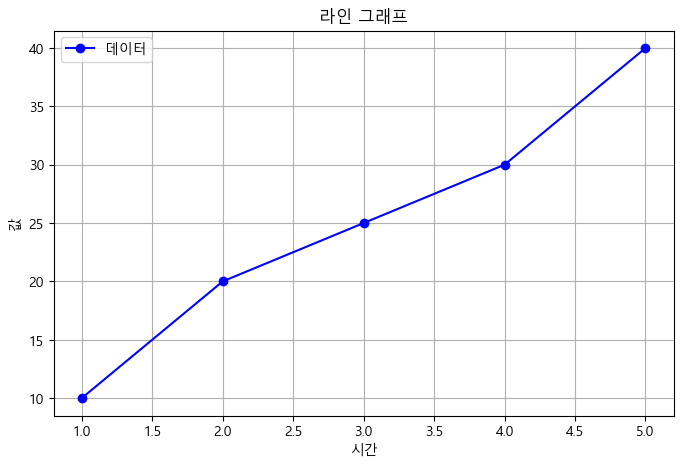

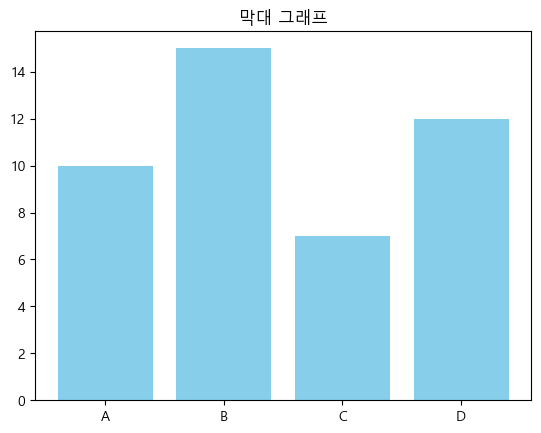

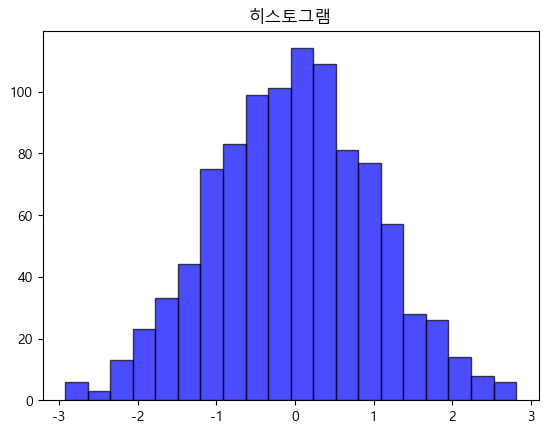

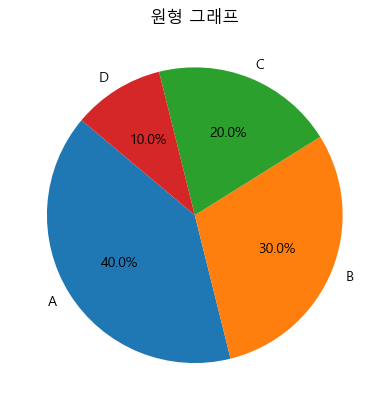

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

# (위 0번의 한글 폰트 설정을 먼저 실행)

# 1) 라인 그래프 — 추세
x = [1, 2, 3, 4, 5]
y = [10, 20, 25, 30, 40]
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='데이터')
plt.title('라인 그래프'); plt.xlabel('시간'); plt.ylabel('값')
plt.legend(); plt.grid(True)
plt.show()

# 2) 막대 그래프 — 카테고리 비교
plt.bar(['A', 'B', 'C', 'D'], [10, 15, 7, 12], color='skyblue')
plt.title('막대 그래프'); plt.show()

# 3) 히스토그램 — 분포
data = np.random.randn(1000)
plt.hist(data, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title('히스토그램'); plt.show()

# 4) 원형 그래프 — 비율
plt.pie([40, 30, 20, 10], labels=['A','B','C','D'], autopct='%1.1f%%', startangle=140)
plt.title('원형 그래프'); plt.show()

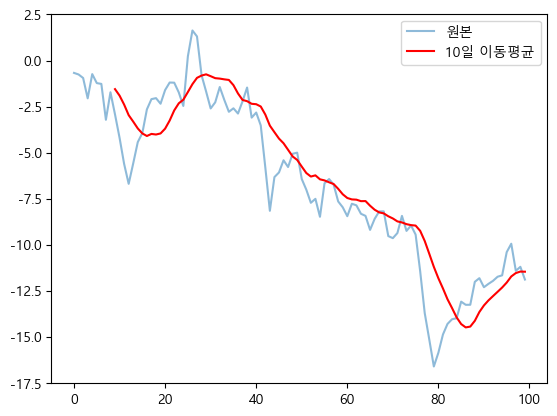

In [6]:
# 시계열 이동평균 (빅데이터 분석 단골)
data = np.cumsum(np.random.randn(100))
rolling = pd.Series(data).rolling(window=10).mean()
plt.plot(data, label='원본', alpha=0.5)
plt.plot(rolling, label='10일 이동평균', color='red')
plt.legend(); plt.show()